***CELL 1 - Imports & Setup***


Sets up all libraries and global plot settings ince, seed = 42 is used anywhere randomness appears so results are reproducable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#consistent plot style throughout
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10,5)

DATA_PATH = 'FedEx_ShipmentDetail.xlsx'
SEED = 42


***CELL 2 - Load the Data***

Reads the Excel file and shows the first 3 rows. Confirms you have 53,014 rows x 65 Columns

In [4]:
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 53,014 rows x 65 columns


,Payer Account,Invoice Month (yyyymm),OPCO,Service Type,Service Description,Pay Type,Shipment Date (mm/dd/yyyy),Shipment Delivery Date (mm/dd/yyyy),Shipment Tracking Number,Shipper Name,...,Shipment Delivery Time (12 Hours),Shipment Freight Charge Billed Currency,Shipment Miscellaneous Charge Billed Currency,Shipment Duty and Tax Charge Billed Currency,Shipment Discount Billed Currency,Net Charge Billed Currency,Billed Currency Code,Exchange Rate to USD,Weight Type Code,Customer Order Number
0,202488358,202206,Express,ES,FedEx 2Day,Bill_Recipient,05/25/2022,05/27/2022,273544596140,Shipping Manager,...,10:23,36.85,5.76,0.0,-11.80,30.81,USD,1,lb,
1,202488358,202206,Express,ES,FedEx 2Day,Bill_Recipient,05/25/2022,05/27/2022,776959929530,MICHAEL PIERCE,...,10:23,46.57,16.03,0.0,-14.91,47.69,USD,1,lb,
2,202488358,202206,Express,FO,FedEx First Overnight,Bill_Recipient,06/24/2022,06/27/2022,274737756885,Shipping Manager,...,07:49,159.02,37.37,0.0,0.00,196.39,USD,1,lb,


***CELL 3 - Null Audit***

Builds a summary table of every column's data type, null count, null %, and number of unique values. The display() call renders it as a formatted table in Jupyter

In [5]:
audit = pd.DataFrame({
    'dtype': df.dtypes, 
    'nulls': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(1),
    'n_unique': df.nunique()
})

high_null = audit[audit['null_pct'] > 5].sort_values('null_pct', ascending=False)
print(f"Columns with >5% nulls ({len(high_null)} of {len(audit)}):")
display(high_null)

print("\nAll columns:")
display(audit)

Columns with >5% nulls (4 of 65):


,dtype,nulls,null_pct,n_unique
Customs Value Currency Code,object,52989,100.0,1
Department Number,object,52983,99.9,20
Recipient Original State/Province,object,52576,99.2,47
PO Number,object,18133,34.2,22835



All columns:


,dtype,nulls,null_pct,n_unique
Payer Account,int64,0,0.0,6
Invoice Month (yyyymm),int64,0,0.0,25
OPCO,object,0,0.0,2
Service Type,object,0,0.0,18
Service Description,object,0,0.0,20
...,...,...,...,...
Net Charge Billed Currency,float64,0,0.0,8522
Billed Currency Code,object,0,0.0,1
Exchange Rate to USD,int64,0,0.0,1
Weight Type Code,object,0,0.0,1


***CELL 4 - Confirm Zero-Variance Columns***

Verifies that some columns are safe to drop because they only ever have one value (no information). You'll see all shipments are in lb, all USD, all domestic

In [6]:
print("Weight Tpye Code unique values: ", df['Weight Type Code'].unique())
print("Billed Currency Code unique values: ", df['Billed Currency Code'].unique())
print("Exchange Rate unique values: ", df['Exchange Rate to USD'].unique())
print("Domestic/Intl breakdown: ")
print(df['Domestic/Intl'].value_counts())

Weight Tpye Code unique values:  ['lb']
Billed Currency Code unique values:  ['USD']
Exchange Rate unique values:  [1]
Domestic/Intl breakdown: 
Domestic/Intl
Domestic         52924
International       90
Name: count, dtype: int64


***CELL 5 - Investigate Null DIM Rows***

The 485 rows with no DIM flag turn out to all be NonTrans(non-transport charges like fuel surcharges billed separetely). These aren't real shipments, so we drop them.

In [7]:
print("Dim flag nulls:", df['Shipment DIM Flag (Y or N)'].isnull().sum())
print('Service type for null DIM rows:')
print(df[df['Shipment DIM Flag (Y or N)'].isnull()]['Service Type'].value_counts())

Dim flag nulls: 485
Service type for null DIM rows:
Service Type
NonTrans    485
Name: count, dtype: int64


***CELL 6 - Drop Null DIM Rows & Plot Class Distribution***

Creates df_clean without the non-transport rows, then plots a bar chart and pie chart of the DIM flag split. The enumerate loop adds count labels above each bar.

After dropping null DIM rows: 52,529 shipments


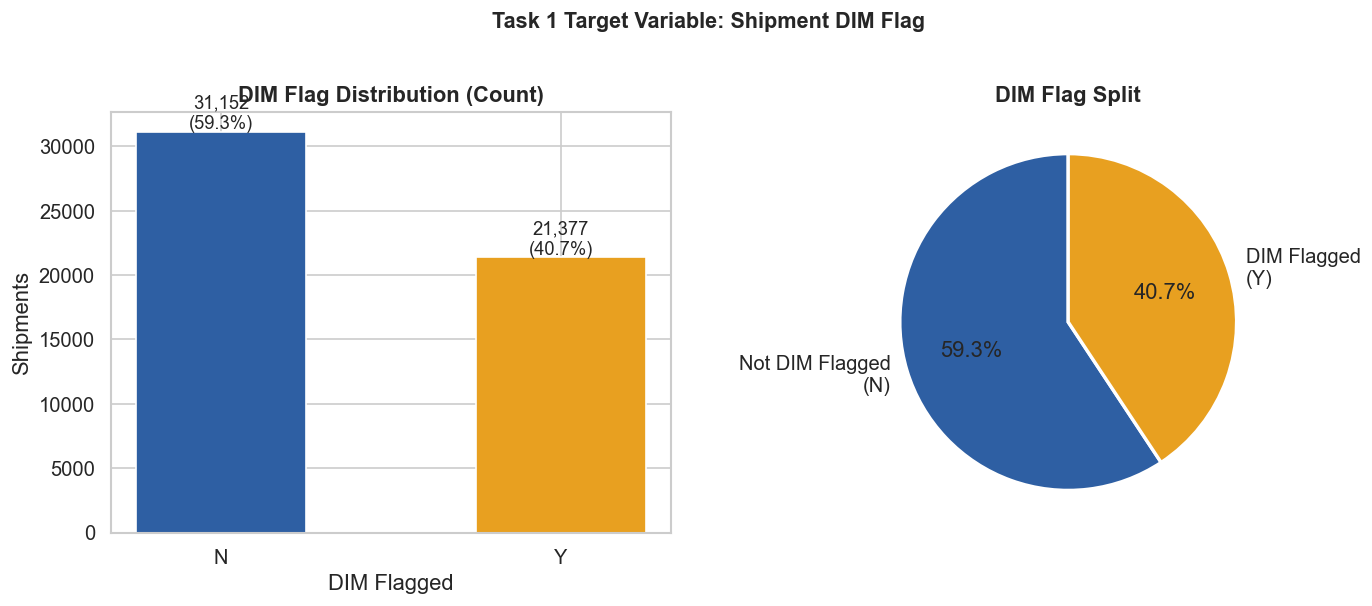


Class imbalance ratio: 1.46:1 (N:Y)


In [8]:
df_clean = df[df['Shipment DIM Flag (Y or N)'].notna()].copy()
print(f"After dropping null DIM rows: {len(df_clean):,} shipments")

dim_counts = df_clean['Shipment DIM Flag (Y or N)'].value_counts()
dim_pct = df_clean['Shipment DIM Flag (Y or N)'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1,2, figsize=(12,5))

colors = ['#2E5FA3', '#E8A020']
axes[0].bar(dim_counts.index, dim_counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('DIM Flag Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('DIM Flagged')
axes[0].set_ylabel('Shipments')

for i, (k, v) in enumerate(dim_counts.items()):
    axes[0].text(i, v + 200, f'{v:,}\n({dim_pct[k]:.1f}%)', ha='center', fontsize=11)

axes[1].pie(dim_counts.values, labels=['Not DIM Flagged\n(N)', 'DIM Flagged\n(Y)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('DIM Flag Split', fontweight='bold')

plt.suptitle('Task 1 Target Variable: Shipment DIM Flag', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch/figures/01_dim_flag_distribution.png', bbox_inches='tight')
plt.show()
print(f'\nClass imbalance ratio: {dim_counts["N"]/dim_counts["Y"]:.2f}:1 (N:Y)')


***CELL 7 - Weight Summary by DIM Flag***

Splits the data into DIM=Y and DIM=N subsets(used in many cells after this). Prints the key stat from the proposal: DIM=Y packages get billed ~15.8lbs over their actual weight.

In [9]:
dim_y = df_clean[df_clean['Shipment DIM Flag (Y or N)'] == 'Y']
dim_n = df_clean[df_clean['Shipment DIM Flag (Y or N)'] == 'N']

dim_y_uplift = dim_y['Shipment Rated Weight(Pounds)'] - dim_y['Original Weight (Pounds)']

print('=== Weight Summary by DIM Flag ===')
print(f"DIM=Y  |  Avg actual: {dim_y['Original Weight (Pounds)'].mean():.1f} lbs  |  "
      f"Avg rated: {dim_y['Shipment Rated Weight(Pounds)'].mean():.1f} lbs  |  "
      f"Avg uplift: +{dim_y_uplift.mean():.1f} lbs")
print(f"DIM=N  |  Avg actual: {dim_n['Original Weight (Pounds)'].mean():.1f} lbs  |  "
      f"Avg rated: {dim_n['Shipment Rated Weight(Pounds)'].mean():.1f} lbs  |  No uplift")

=== Weight Summary by DIM Flag ===
DIM=Y  |  Avg actual: 51.1 lbs  |  Avg rated: 66.9 lbs  |  Avg uplift: +15.8 lbs
DIM=N  |  Avg actual: 104.1 lbs  |  Avg rated: 104.3 lbs  |  No uplift


***CELL 8 - Weight Distribution Plots***

Three side-by-side overlapping histograms of actual weight by DIM flag, a scatter of rated vs actual for DIM=Y shipments(points above the dashed line = overbilled), and the uplift distribution

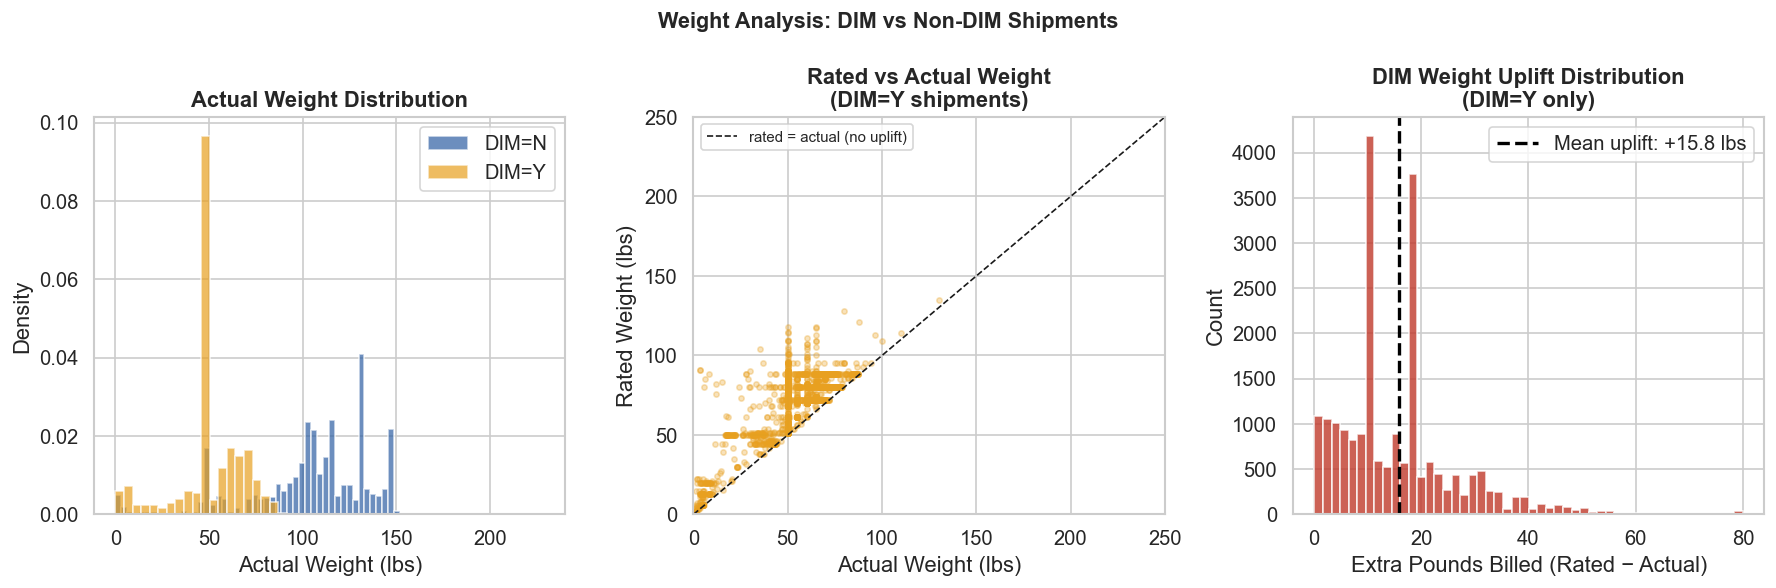

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Actual weight distribution by DIM flag
axes[0].hist(dim_n['Original Weight (Pounds)'].clip(upper=250), bins=50,
             alpha=0.7, color='#2E5FA3', label='DIM=N', density=True)
axes[0].hist(dim_y['Original Weight (Pounds)'].clip(upper=250), bins=50,
             alpha=0.7, color='#E8A020', label='DIM=Y', density=True)
axes[0].set_title('Actual Weight Distribution', fontweight='bold')
axes[0].set_xlabel('Actual Weight (lbs)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Rated vs Actual for DIM=Y only
sample = dim_y.sample(min(2000, len(dim_y)), random_state=SEED)
axes[1].scatter(sample['Original Weight (Pounds)'], sample['Shipment Rated Weight(Pounds)'],
                alpha=0.3, s=10, color='#E8A020')
lims = [0, 250]
axes[1].plot(lims, lims, 'k--', lw=1, label='rated = actual (no uplift)')
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_title('Rated vs Actual Weight\n(DIM=Y shipments)', fontweight='bold')
axes[1].set_xlabel('Actual Weight (lbs)')
axes[1].set_ylabel('Rated Weight (lbs)')
axes[1].legend(fontsize=9)

# DIM weight uplift histogram
axes[2].hist(dim_y_uplift[dim_y_uplift > 0].clip(upper=80), bins=50, color='#C0392B', alpha=0.8)
axes[2].axvline(dim_y_uplift.mean(), color='black', linestyle='--', lw=2,
                label=f'Mean uplift: +{dim_y_uplift.mean():.1f} lbs')
axes[2].set_title('DIM Weight Uplift Distribution\n(DIM=Y only)', fontweight='bold')
axes[2].set_xlabel('Extra Pounds Billed (Rated − Actual)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Weight Analysis: DIM vs Non-DIM Shipments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch/figures/02_weight_analysis.png', bbox_inches='tight')
plt.show()

***CELL 9 - Leakage Verification***

This is the most important cell. Trains a trivial logistic regression using only rated_weight as input and scores near-perfect AUC, proof it's a leaked feature. Then shows actual_weight alone geta a legitimate but much lower AUC

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_clean['Shipment DIM Flag (Y or N)'])

#AUC using only rated weight (leakage feature)
X_leak = df_clean[['Shipment Rated Weight(Pounds)']].values
auc_leak = roc_auc_score(y, X_leak)

#AUC using only actual weight (safe feature)
X_safe = df_clean[['Original Weight (Pounds)']].values
auc_safe = roc_auc_score(y, -X_safe) #negative: lighter = more likely DIM

# Corrected interpretation
print('=== LEAKAGE CHECK ===')
print(f'Effective AUC of RATED weight: {1 - auc_leak:.4f}  (inverted — DIM=Y packages are lighter)')
print(f'Effective AUC of ACTUAL weight: {auc_safe:.4f}  (strong legitimate signal — lighter = more likely DIM)')
print()
print('► rated_weight - actual_weight would be near-perfect (true leakage source)')
print('► Exclude: Shipment Rated Weight(Pounds) from ALL Task 1 inputs')

=== LEAKAGE CHECK ===
Effective AUC of RATED weight: 0.8489  (inverted — DIM=Y packages are lighter)
Effective AUC of ACTUAL weight: 0.9056  (strong legitimate signal — lighter = more likely DIM)

► rated_weight - actual_weight would be near-perfect (true leakage source)
► Exclude: Shipment Rated Weight(Pounds) from ALL Task 1 inputs


***CELL 10 - Engineer Features & Check Zero Dimensions***

Ceates the 3 engineered features from the proposal. Also checks how many shipments have zero dimensions, those need special handling in preprocessing.

In [12]:
df_clean['volume'] = df_clean['Dimmed Height (in)'] * df_clean['Dimmed Length (in)'] * df_clean['Dimmed Width (in)']
df_clean['dim_weight_calc'] = df_clean['volume'] / 139
df_clean['dim_weight_ratio'] = df_clean['dim_weight_calc'] / df_clean['Original Weight (Pounds)'].replace(0,np.nan)

zero_dims = df_clean[(df_clean['Dimmed Height (in)'] == 0) |
                     (df_clean['Dimmed Width (in)'] == 0) |
                     (df_clean['Dimmed Length (in)'] == 0)]
print(f'Shipments with at least one zero dimension: {len(zero_dims):,} ({len(zero_dims)/len(df_clean)*100:.1f}%)')
print('DIM flag for zero-dimension shipments:')
print(zero_dims['Shipment DIM Flag (Y or N)'].value_counts())

Shipments with at least one zero dimension: 493 (0.9%)
DIM flag for zero-dimension shipments:
Shipment DIM Flag (Y or N)
N    490
Y      3
Name: count, dtype: int64


***CELL 11 - Dimension Distribution Plots***

Six charts in a 2x3 grid: distributions of height, width, and length by DIM flag, then volume distribution, DIM ratio histogram, and a scatter of volume vs actual weight colored by DIM flag

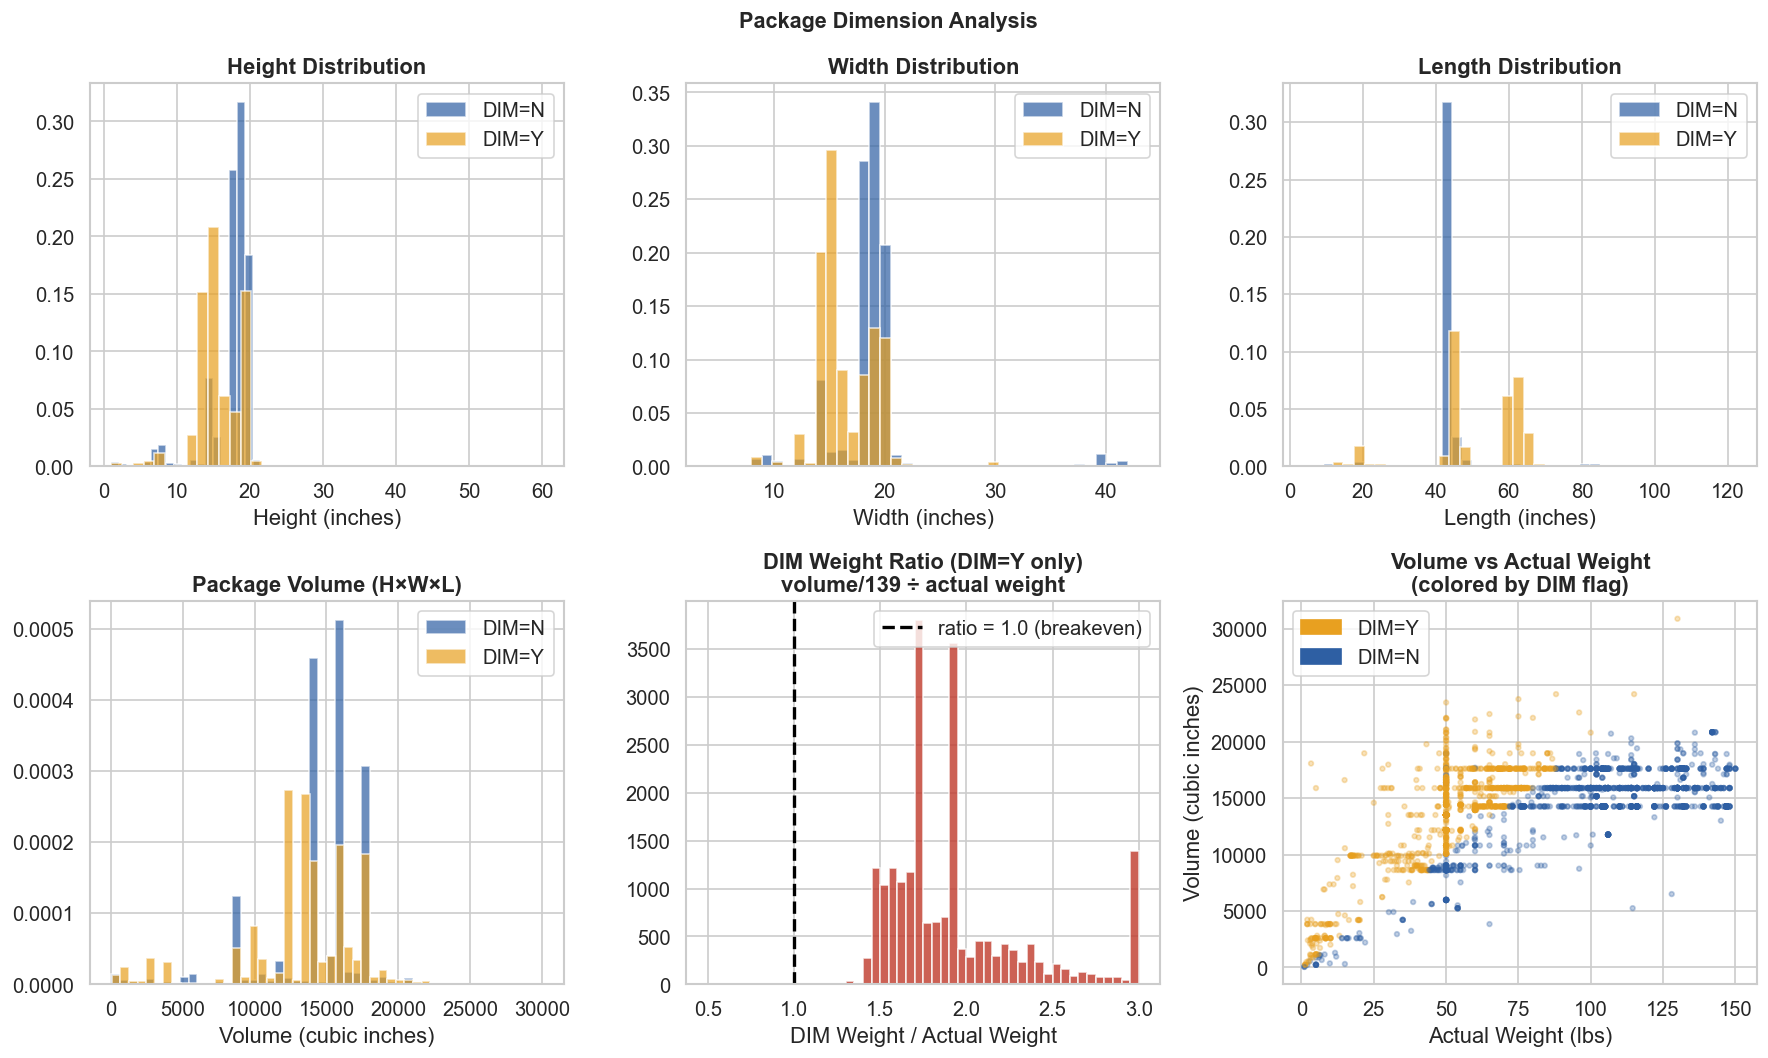

In [13]:
from matplotlib.patches import Patch

valid = df_clean[df_clean['volume'] > 0]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

dims = [('Dimmed Height (in)', 'Height'), ('Dimmed Width (in)', 'Width'), ('Dimmed Length (in)', 'Length')]
for i, (col, label) in enumerate(dims):
    axes[0, i].hist(valid[valid['Shipment DIM Flag (Y or N)']=='N'][col], bins=40,
                    alpha=0.7, color='#2E5FA3', label='DIM=N', density=True)
    axes[0, i].hist(valid[valid['Shipment DIM Flag (Y or N)']=='Y'][col], bins=40,
                    alpha=0.7, color='#E8A020', label='DIM=Y', density=True)
    axes[0, i].set_title(f'{label} Distribution', fontweight='bold')
    axes[0, i].set_xlabel(f'{label} (inches)')
    axes[0, i].legend()

axes[1, 0].hist(valid[valid['Shipment DIM Flag (Y or N)']=='N']['volume'].clip(upper=30000), bins=50,
                alpha=0.7, color='#2E5FA3', label='DIM=N', density=True)
axes[1, 0].hist(valid[valid['Shipment DIM Flag (Y or N)']=='Y']['volume'].clip(upper=30000), bins=50,
                alpha=0.7, color='#E8A020', label='DIM=Y', density=True)
axes[1, 0].set_title('Package Volume (H×W×L)', fontweight='bold')
axes[1, 0].set_xlabel('Volume (cubic inches)')
axes[1, 0].legend()

valid_y = valid[valid['Shipment DIM Flag (Y or N)']=='Y']
axes[1, 1].hist(valid_y['dim_weight_ratio'].clip(upper=3), bins=50, color='#C0392B', alpha=0.8)
axes[1, 1].axvline(1, color='black', linestyle='--', lw=2, label='ratio = 1.0 (breakeven)')
axes[1, 1].set_title('DIM Weight Ratio (DIM=Y only)\nvolume/139 ÷ actual weight', fontweight='bold')
axes[1, 1].set_xlabel('DIM Weight / Actual Weight')
axes[1, 1].legend()

samp = df_clean[df_clean['volume']>0].sample(3000, random_state=SEED)
colors_map = samp['Shipment DIM Flag (Y or N)'].map({'Y': '#E8A020', 'N': '#2E5FA3'})
axes[1, 2].scatter(samp['Original Weight (Pounds)'], samp['volume'],
                   c=colors_map, alpha=0.3, s=8)
axes[1, 2].set_title('Volume vs Actual Weight\n(colored by DIM flag)', fontweight='bold')
axes[1, 2].set_xlabel('Actual Weight (lbs)')
axes[1, 2].set_ylabel('Volume (cubic inches)')
axes[1, 2].legend(handles=[Patch(color='#E8A020', label='DIM=Y'), Patch(color='#2E5FA3', label='DIM=N')])

plt.suptitle('Package Dimension Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch/figures/03_dimension_analysis.png', bbox_inches='tight')
plt.show()

***CELL 12- Net Charge Stats***

Quick statistical summary of the regression target. Checks the skewness and counts outliers above $500

In [14]:
net = df_clean['Net Charge Amount USD']
print('Net Charge Summary:')
print(net.describe().round(2))
print(f'\nSkewness: {net.skew():.3f}')
print(f'Shipments with $0 charge: {(net == 0).sum()}')
print(f'Shipments > $500: {(net > 500).sum()} ({(net>500).sum()/len(net)*100:.1f}%)')

Net Charge Summary:
count    52529.00
mean        58.87
std         42.39
min          0.00
25%         42.23
50%         55.60
75%         70.01
max       3501.76
Name: Net Charge Amount USD, dtype: float64

Skewness: 23.212
Shipments with $0 charge: 8
Shipments > $500: 53 (0.1%)


***CELL 13- Net Charge Distribution Plots***

Three charts: raw distribution with mean/median lines, log-transformed version (to check if it normalizes nicely), and box plots split by DIM flag. The counterintuitive finding, DIM=N costs more, shows up clearly here

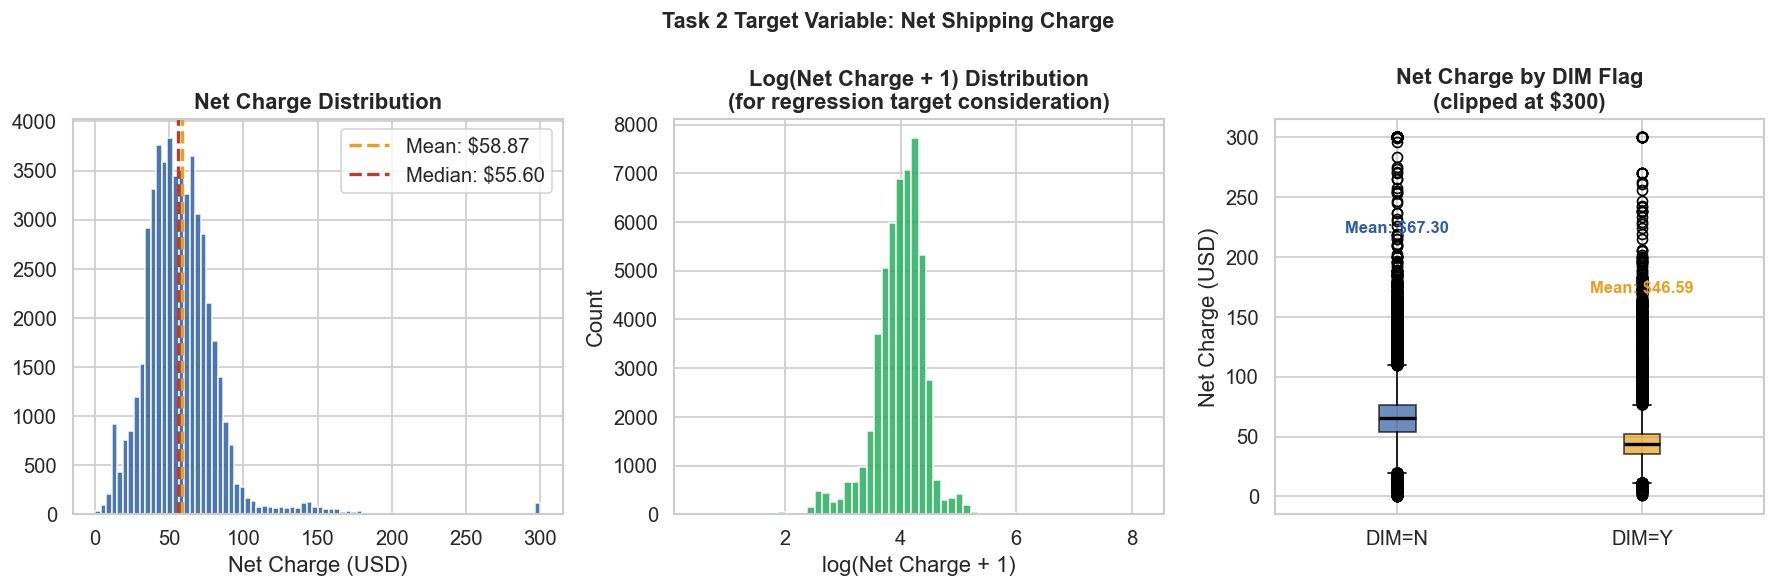


► DIM=N packages cost MORE on average ($67.30 vs $46.59) because non-DIM shipments are physically heavier.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(net.clip(upper=300), bins=80, color='#2E5FA3', alpha=0.85, edgecolor='white')
axes[0].axvline(net.mean(), color='#E8A020', lw=2, linestyle='--', label=f'Mean: ${net.mean():.2f}')
axes[0].axvline(net.median(), color='#C0392B', lw=2, linestyle='--', label=f'Median: ${net.median():.2f}')
axes[0].set_title('Net Charge Distribution', fontweight='bold')
axes[0].set_xlabel('Net Charge (USD)')
axes[0].legend()

log_net = np.log1p(net[net > 0])
axes[1].hist(log_net, bins=60, color='#27AE60', alpha=0.85, edgecolor='white')
axes[1].set_title('Log(Net Charge + 1) Distribution\n(for regression target consideration)', fontweight='bold')
axes[1].set_xlabel('log(Net Charge + 1)')
axes[1].set_ylabel('Count')

bp_data = [dim_n['Net Charge Amount USD'].clip(upper=300),
           dim_y['Net Charge Amount USD'].clip(upper=300)]
bp = axes[2].boxplot(bp_data, patch_artist=True, labels=['DIM=N', 'DIM=Y'],
                     medianprops={'color': 'black', 'lw': 2})
for patch, color in zip(bp['boxes'], ['#2E5FA3', '#E8A020']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Net Charge by DIM Flag\n(clipped at $300)', fontweight='bold')
axes[2].set_ylabel('Net Charge (USD)')
axes[2].text(1, 220, f'Mean: ${dim_n["Net Charge Amount USD"].mean():.2f}', ha='center', fontsize=10, color='#2E5FA3', fontweight='bold')
axes[2].text(2, 170, f'Mean: ${dim_y["Net Charge Amount USD"].mean():.2f}', ha='center', fontsize=10, color='#E8A020', fontweight='bold')

plt.suptitle('Task 2 Target Variable: Net Shipping Charge', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch/figures/04_net_charge_analysis.png', bbox_inches='tight')
plt.show()

print('\n► DIM=N packages cost MORE on average ($67.30 vs $46.59) because non-DIM shipments are physically heavier.')

***CELL 14 - Raw Pricing Zone Values***

Prints the raw values so oyu can see the dirty data problem, "2" and "02" are the same zone but treated as different

In [16]:
print('Raw Pricing Zone values:')
print(df_clean['Pricing Zone'].value_counts().to_string())
print('\n► Zones 2,3,4,5,6,7,8 are duplicate formats of 02,03,04,05,06,07,08')

Raw Pricing Zone values:
Pricing Zone
05          11431
08          11285
06          11139
07           6292
04           6106
02           3760
03           1724
00            205
6             195
8             162
2              70
4              37
51             30
7              17
5              16
Non Zone       14
09             13
D               7
17              6
A               5
C               4
3               3
N               2
54              2
K               1
J               1
52              1
53              1

► Zones 2,3,4,5,6,7,8 are duplicate formats of 02,03,04,05,06,07,08


***CELL 15- Categorical Feature Plots***

Normalizes the zones with a small helper function, then makes two charts: DIM rate per zone(bar), and DIM rate per service type(horizontal bar). Bars. above the average are highlighted in orange.

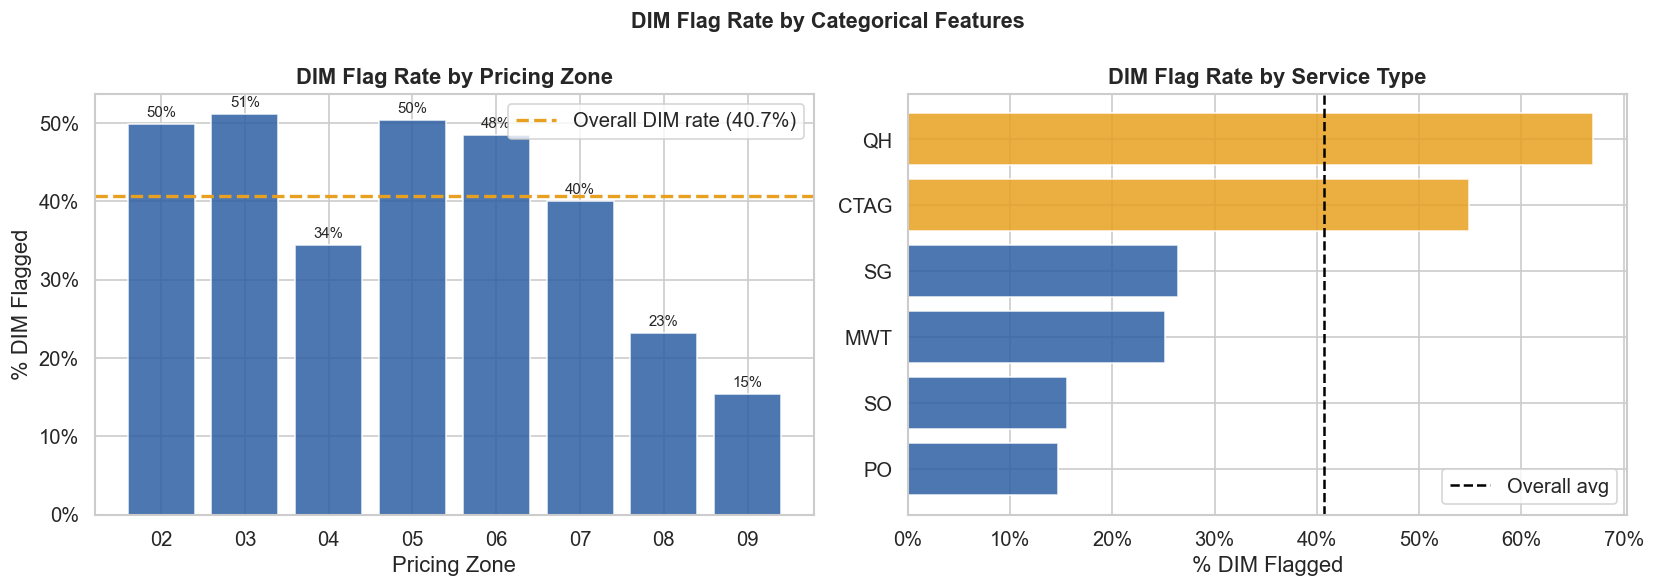

In [17]:
def normalize_zone(z):
    try:
        return f'{int(z):02d}'
    except:
        return z

df_clean['zone_clean'] = df_clean['Pricing Zone'].apply(normalize_zone)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

zone_dim = (df_clean[df_clean['Shipment DIM Flag (Y or N)'].isin(['Y','N'])]
            .groupby('zone_clean')['Shipment DIM Flag (Y or N)']
            .apply(lambda x: (x=='Y').mean() * 100)
            .sort_index())

valid_zones = zone_dim[zone_dim.index.isin(['02','03','04','05','06','07','08','09'])]
bars = axes[0].bar(valid_zones.index, valid_zones.values, color='#2E5FA3', alpha=0.85, edgecolor='white')
axes[0].axhline(40.7, color='#E8A020', linestyle='--', lw=2, label='Overall DIM rate (40.7%)')
axes[0].set_title('DIM Flag Rate by Pricing Zone', fontweight='bold')
axes[0].set_xlabel('Pricing Zone')
axes[0].set_ylabel('% DIM Flagged')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()
for bar, val in zip(bars, valid_zones.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

svc_dim = (df_clean[df_clean['Shipment DIM Flag (Y or N)'].isin(['Y','N'])]
           .groupby('Service Type')['Shipment DIM Flag (Y or N)']
           .apply(lambda x: (x=='Y').mean() * 100))
svc_counts  = df_clean['Service Type'].value_counts()
top_svcs    = svc_counts[svc_counts > 100].index
svc_dim_top = svc_dim[svc_dim.index.isin(top_svcs)].sort_values(ascending=True)

colors_svc = ['#E8A020' if v > 40.7 else '#2E5FA3' for v in svc_dim_top.values]
axes[1].barh(svc_dim_top.index, svc_dim_top.values, color=colors_svc, alpha=0.85, edgecolor='white')
axes[1].axvline(40.7, color='black', linestyle='--', lw=1.5, label='Overall avg')
axes[1].set_title('DIM Flag Rate by Service Type', fontweight='bold')
axes[1].set_xlabel('% DIM Flagged')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()

plt.suptitle('DIM Flag Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch/figures/05_dim_by_category.png', bbox_inches='tight')
plt.show()

***CELL 16- Correlation Heatmap***

Builds a lower-triangle heatmap of all key numeric features. Rated weight is included deliberately and labeled with ⚠️, it should show a very strong negative correlation with DIM flag, visually proving the leakage

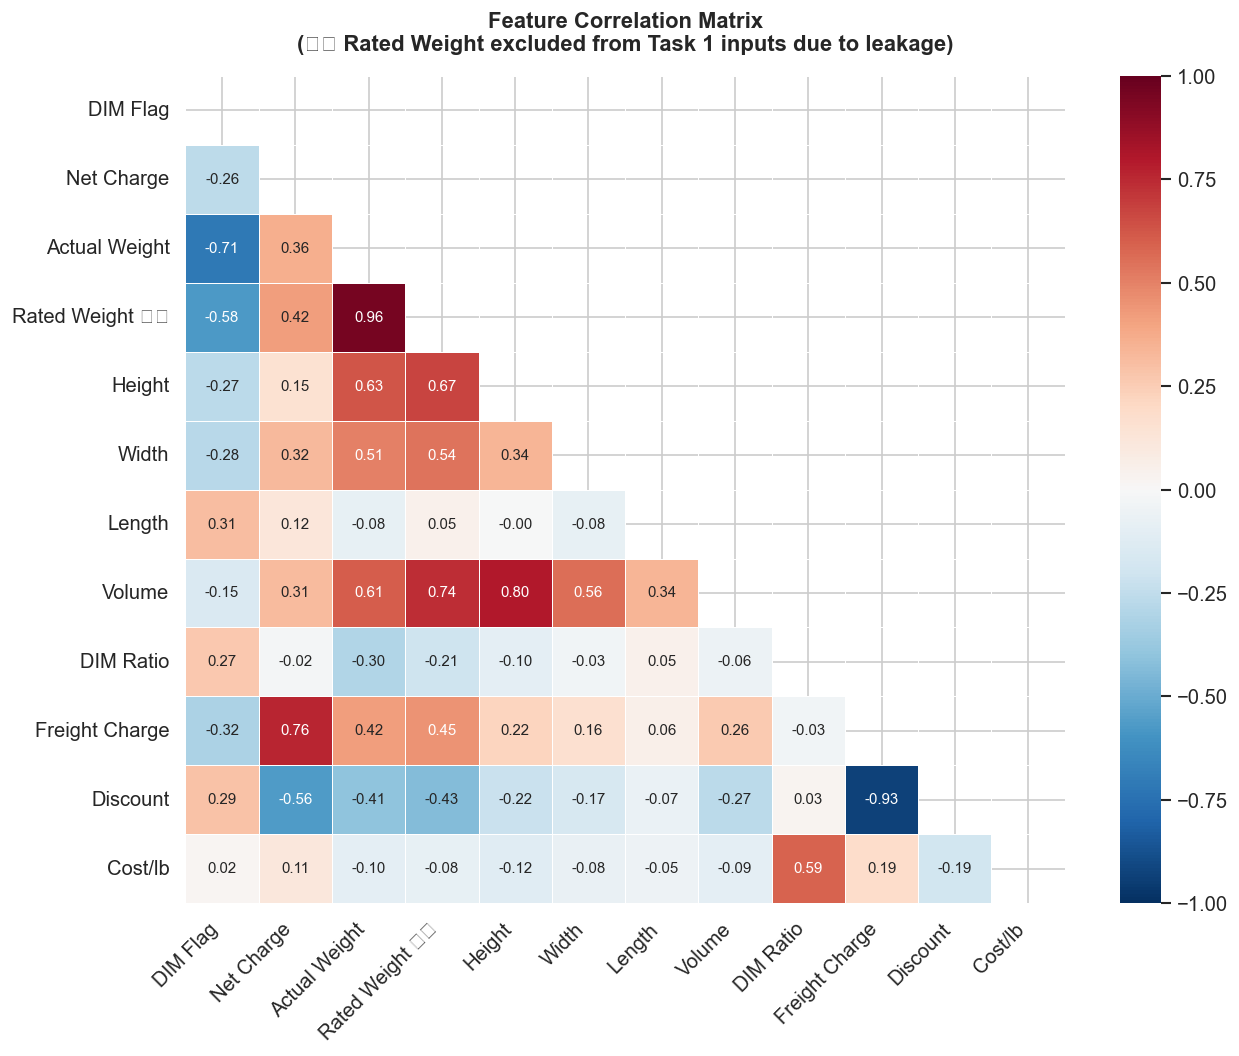

In [18]:
df_clean['dim_flag_int']   = (df_clean['Shipment DIM Flag (Y or N)'] == 'Y').astype(int)
df_clean['cost_per_pound'] = df_clean['Shipment Freight Charge Amount USD'] / df_clean['Original Weight (Pounds)'].replace(0, np.nan)

corr_cols = [
    'dim_flag_int', 'Net Charge Amount USD', 'Original Weight (Pounds)',
    'Shipment Rated Weight(Pounds)', 'Dimmed Height (in)', 'Dimmed Width (in)',
    'Dimmed Length (in)', 'volume', 'dim_weight_ratio',
    'Shipment Freight Charge Amount USD', 'Shipment Discount Amount USD', 'cost_per_pound'
]
corr_labels = [
    'DIM Flag', 'Net Charge', 'Actual Weight', 'Rated Weight ⚠️',
    'Height', 'Width', 'Length', 'Volume', 'DIM Ratio',
    'Freight Charge', 'Discount', 'Cost/lb'
]

corr_df = df_clean[corr_cols].dropna().corr()
corr_df.index   = corr_labels
corr_df.columns = corr_labels

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix\n(⚠️ Rated Weight excluded from Task 1 inputs due to leakage)',
          fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch/figures/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

***CELL 17- EDA Summary***

Prints a structured log that feeds directly into the next notebook. Everything notes here get implemented in 02_preprocessing.py

In [19]:
print('=' * 65)
print('EDA SUMMARY')
print('=' * 65)

print(f"""
DATASET
  Total shipments       : {len(df):,}
  After dropping nulls  : {len(df_clean):,}
  DIM=Y (positive class): {dim_y.shape[0]:,}  ({dim_y.shape[0]/len(df_clean)*100:.1f}%)
  DIM=N (negative class): {dim_n.shape[0]:,}  ({dim_n.shape[0]/len(df_clean)*100:.1f}%)

TASK 1 — CLASSIFICATION NOTES
  • Class imbalance 1.46:1 (N:Y) — mild, use class_weight='balanced'
  • ⚠️  Rated weight MUST be excluded (near-perfect leakage feature)
  • Best raw predictors: volume, actual weight, DIM ratio, service type
  • 978 shipments have zero dimensions — impute or flag with indicator

TASK 2 — REGRESSION NOTES
  • Net charge mean ${net.mean():.2f}, median ${net.median():.2f}, skew={net.skew():.2f}
  • Right-skewed with outliers — consider log transform or Huber loss
  • DIM=N shipments cost MORE on avg — DIM flag is a useful regression feature
  • Discount amount is always negative (max ${df_clean['Shipment Discount Amount USD'].min():.2f})

PREPROCESSING DECISIONS
  • Drop: Department Number, Customs Value Currency Code,
          Recipient Original State/Province, Weight Type Code,
          Billed Currency Code, Exchange Rate to USD,
          all address/name/identifier columns
  • Normalize Pricing Zone: '2' → '02', '3' → '03', etc.
  • Encode: Pricing Zone (ordinal/OHE), Service Type (OHE), Pay Type (OHE)
  • Scale: Standard scaling for neural network; raw for tree models
  • Engineer: volume, dim_weight_ratio, cost_per_pound
  • Split: 80/10/10 stratified on DIM flag
""")

print('=' * 65)
print('Next: 02_preprocessing.py')

EDA SUMMARY

DATASET
  Total shipments       : 53,014
  After dropping nulls  : 52,529
  DIM=Y (positive class): 21,377  (40.7%)
  DIM=N (negative class): 31,152  (59.3%)

TASK 1 — CLASSIFICATION NOTES
  • Class imbalance 1.46:1 (N:Y) — mild, use class_weight='balanced'
  • ⚠️  Rated weight MUST be excluded (near-perfect leakage feature)
  • Best raw predictors: volume, actual weight, DIM ratio, service type
  • 978 shipments have zero dimensions — impute or flag with indicator

TASK 2 — REGRESSION NOTES
  • Net charge mean $58.87, median $55.60, skew=23.21
  • Right-skewed with outliers — consider log transform or Huber loss
  • DIM=N shipments cost MORE on avg — DIM flag is a useful regression feature
  • Discount amount is always negative (max $-1480.83)

PREPROCESSING DECISIONS
  • Drop: Department Number, Customs Value Currency Code,
          Recipient Original State/Province, Weight Type Code,
          Billed Currency Code, Exchange Rate to USD,
          all address/name/ident

In [20]:
nums = [1,2,3,4,5,6]
for i in range(1,len(nums), 2):
    print(i)
    
print("done")
    


1
3
5
done
